In [1]:
import os
import sys
import torch
import torch.nn as nn
import random
import numpy as np
from typing import Tuple, Optional
from torch.utils.data import IterableDataset, DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import torch.nn.functional as F
from sklearn.neighbors import NearestNeighbors
import numpy as np

from cvae_model import CVAE, cvae_loss
from discriminator import Discriminator

In [ ]:
# -------- 1) Build an "embedder" from your Discriminator (up to the 128-D LeakyReLU) --------
def get_embedder(discriminator: nn.Module) -> nn.Module:
    """
    Returns a module that outputs the penultimate 128-D embedding:
    Conv -> LeakyReLU -> Conv -> LeakyReLU -> Flatten -> Linear(64*7*7->128) -> LeakyReLU
    """
    layers = list(discriminator.net.children())[:-2]  # drop final Linear(128->1) and Sigmoid
    embedder = nn.Sequential(*layers)
    # share weights; keep device consistent
    embedder.to(next(discriminator.parameters()).device)
    embedder.eval()
    return embedder

@torch.no_grad()
def extract_real_embeddings(discriminator: nn.Module,
                            real_loader,  # DataLoader yielding (images, labels)
                            device='cuda',
                            l2_normalize=True):
    """
    Returns:
        E: np.ndarray, shape (N, 128)   penultimate embeddings for real images
        y: np.ndarray, shape (N,)       integer class labels
    """
    embedder = get_embedder(discriminator)
    all_e, all_y = [], []
    for xb, yb in real_loader:
        xb = xb.to(device)
        h = embedder(xb)                       # (B, 128)
        if l2_normalize:
            h = F.normalize(h, p=2, dim=1)     # recommended for Euclidean distances
        all_e.append(h.cpu())
        all_y.append(yb.cpu())
    E = torch.cat(all_e, dim=0).numpy()
    y = torch.cat(all_y, dim=0).numpy()
    return E, y

# -------- 2) Compute per-class second-NN quantiles (q50, q90, q95) --------
def nn_quantiles_per_class(E_real: np.ndarray,
                           y_real: np.ndarray,
                           classes=None,
                           subsample_per_class: int = None):
    """
    For each class c, compute the distribution of 'second nearest neighbor' distances among real samples
    and return its quantiles q50, q90, q95.

    Args:
      E_real: (N, d) embeddings (ideally L2-normalized)
      y_real: (N,) integer labels
      classes: iterable of classes to compute (default: unique labels)
      subsample_per_class: if set, randomly cap number of real samples per class to this many

    Returns:
      qdict: {c: {'q50': float, 'q90': float, 'q95': float}}
    """
    if classes is None:
        classes = np.unique(y_real)
    qdict = {}

    rng = np.random.default_rng(0)
    for c in classes:
        idx = np.where(y_real == c)[0]
        if len(idx) < 3:
            continue  # need >=3 to get a stable 2-NN distance

        if subsample_per_class is not None and len(idx) > subsample_per_class:
            idx = rng.choice(idx, size=subsample_per_class, replace=False)

        E_c = E_real[idx]

        # 2-NN among real-real (first NN is itself at distance 0)
        nn = NearestNeighbors(n_neighbors=2, algorithm='auto', metric='euclidean')
        nn.fit(E_c)
        dists, _ = nn.kneighbors(E_c)   # shape (n, 2)
        nn2 = dists[:, 1]               # second neighbor distance

        q50, q90, q95 = np.quantile(nn2, [0.5, 0.9, 0.95])
        qdict[int(c)] = {'q50': float(q50), 'q90': float(q90), 'q95': float(q95)}

    return qdict

In [ ]:
def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Hyperparameters
latent_dim = 20
label_dim = 10
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/iter_models_only/model_00_real.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
synthetic_image, synthetic_label = generate_images_in_batches(
            model=model,
            total_samples=60000,
            latent_dim=latent_dim,
            num_classes=10,
            batch_size=10000,
            device=device
        )
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

/tmp/ipykernel_2326489/471147072.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
/tmp/ipykernel_232648

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=3136, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Linear(in_features=128, out_features=1, bias=True)
    (8): Sigmoid()
  )
)

In [5]:
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.neighbors import NearestNeighbors
import torch.nn.functional as F  # for L2 normalize used in extract_real_embeddings

# 1) real MNIST loader
tfm = transforms.ToTensor()
real_ds = datasets.MNIST('./data', train=True, download=True, transform=tfm)
real_loader = DataLoader(real_ds, batch_size=1024, shuffle=False, num_workers=4)

# 2) extract real embeddings (shape: [N, 128]) and labels (shape: [N])
E_real, y_real = extract_real_embeddings(D, real_loader, device=device, l2_normalize=True)

# 3) compute per-class 2-NN quantiles
#    (use subsample_per_class to speed up if needed, e.g., 10000)
qdict = nn_quantiles_per_class(E_real, y_real, subsample_per_class=None)


/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [6]:
from sklearn.metrics import pairwise_distances
# --- settings ---
t_high = 0.90
t_low  = 0.50
diversity_ratio = 0.15      # take ~15% per class from the mid band (tune 0.10~0.20)
batch_size_scoring = 1024
num_classes = 10

# --- helper: k-center greedy for coverage ---
def kcenter_greedy(emb, k):
    """emb: (M,d) L2-normalized embeddings; return indices into emb."""
    M = emb.shape[0]
    if k <= 0: return np.empty(0, dtype=int)
    if M <= k: return np.arange(M, dtype=int)
    centers = [np.random.randint(M)]
    min_dist = pairwise_distances(emb[centers], emb).reshape(-1)
    for _ in range(1, k):
        nxt = int(np.argmax(min_dist))
        centers.append(nxt)
        min_dist = np.minimum(min_dist, pairwise_distances(emb[[nxt]], emb).reshape(-1))
    return np.array(centers, dtype=int)

# --- 0) per-class 1-NN indexers on REAL (for synth→real distance) ---
knn_per_class = {}
for c in range(num_classes):
    idx = np.where(y_real == c)[0]
    if len(idx) == 0: 
        continue
    nn_c = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='euclidean')
    nn_c.fit(E_real[idx])
    knn_per_class[c] = (nn_c, idx)

# --- 1) score synthetic + get embeddings ---
embedder = get_embedder(D).eval().to(device)
D.eval()

N = synthetic_image.size(0)
labels_np = synthetic_label.cpu().numpy()

probs_list, emb_list = [], []
with torch.no_grad():
    for i in range(0, N, batch_size_scoring):
        xb = synthetic_image[i:i+batch_size_scoring].to(device)
        pb = D(xb).squeeze(1).detach().cpu().numpy()       # D has Sigmoid -> probs
        hb = embedder(xb)                                   # (B,128)
        hb = F.normalize(hb, p=2, dim=1).cpu().numpy()      # L2 normalize for Euclidean
        probs_list.append(pb); emb_list.append(hb)
probs = np.concatenate(probs_list, 0)                       # (N,)
E_syn = np.concatenate(emb_list, 0)                         # (N,128)

# --- 2) split by bands ---
high_mask = probs >= t_high
mid_mask  = (probs >= t_low) & (probs < t_high)

# --- 3) ring filter on mid band (distance to nearest REAL of same class) ---
dmin = np.full(N, np.inf, dtype=np.float32)
for c in range(num_classes):
    if c not in knn_per_class: 
        continue
    nn_c, real_idx_c = knn_per_class[c]
    idx_c = np.where((labels_np == c) & mid_mask)[0]
    if len(idx_c) == 0: 
        continue
    dists, _ = nn_c.kneighbors(E_syn[idx_c])    # (m,1)
    dmin[idx_c] = dists[:, 0]

ring_mask = np.zeros(N, dtype=bool)
too_far   = np.zeros(N, dtype=bool)
for c in range(num_classes):
    idx_c = np.where((labels_np == c) & mid_mask)[0]
    if len(idx_c) == 0 or c not in qdict: 
        continue
    q50, q90, q95 = qdict[c]['q50'], qdict[c]['q90'], qdict[c]['q95']
    ring_c = (dmin[idx_c] >= q50) & (dmin[idx_c] <= q90)
    ring_mask[idx_c] = ring_c
    too_far[idx_c]   = dmin[idx_c] > q95

mid_candidates = np.where(mid_mask & ring_mask & (~too_far))[0]

# --- 4) select diverse subset from mid candidates via k-center (per class) ---
selected_diverse = []
for c in range(num_classes):
    idx_c = mid_candidates[labels_np[mid_candidates] == c]
    if len(idx_c) == 0:
        continue
    # budget per class ~15% of (high + ringed mid) for that class
    high_c = np.where((labels_np == c) & high_mask)[0]
    budget = int(np.ceil(diversity_ratio * (len(high_c) + len(idx_c))))
    budget = max(1, min(budget, len(idx_c)))
    centers = kcenter_greedy(E_syn[idx_c], budget)
    selected_diverse.extend(idx_c[centers].tolist())
selected_diverse = np.array(selected_diverse, dtype=int)

# --- 5) final indices & tensors ---
high_idx = np.where(high_mask)[0]                   # keep ALL high-quality p>=0.9
div_idx  = selected_diverse                         # high-diversity from 0.5≤p<0.9

print(f"High-quality kept (p>=0.9): {len(high_idx)}")
print(f"Mid-band ring candidates:   {len(mid_candidates)}")
print(f"Diverse selected (mid band):{len(div_idx)}")

high_images = synthetic_image[torch.from_numpy(high_idx)]
high_labels = synthetic_label[torch.from_numpy(high_idx)]
div_images  = synthetic_image[torch.from_numpy(div_idx)]
div_labels  = synthetic_label[torch.from_numpy(div_idx)]

High-quality kept (p>=0.9): 459
Mid-band ring candidates:   0
Diverse selected (mid band):0


In [7]:
min(dmin)

0.12823862

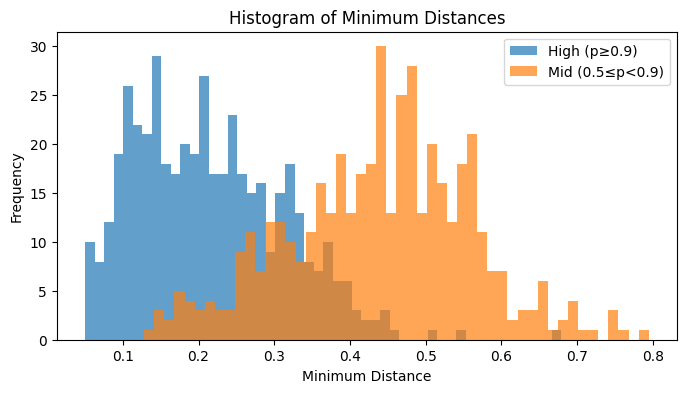

In [8]:
dmin = np.full(N, np.inf, dtype=np.float32)
for c in range(num_classes):
    if c not in knn_per_class: 
        continue
    nn_c, real_idx_c = knn_per_class[c]
    idx_c = np.where(labels_np == c)[0]
    if len(idx_c) == 0: 
        continue
    
    dists, _ = nn_c.kneighbors(E_syn[idx_c])    # (m,1)
    dmin[idx_c] = dists[:, 0]
# plot histgram for dmin
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(dmin[high_mask], bins=50, alpha=0.7, label="High (p≥0.9)")
plt.hist(dmin[mid_mask], bins=50, alpha=0.7, label="Mid (0.5≤p<0.9)")
plt.xlabel("Minimum Distance")
plt.ylabel("Frequency")
plt.title("Histogram of Minimum Distances")
plt.legend()
plt.show()


In [17]:
import numpy as np
from sklearn.metrics import pairwise_distances
import torch, math

def kcenter_greedy(emb, k, seed=0):
    M = emb.shape[0]
    if k <= 0: return np.empty(0, dtype=int)
    if M <= k: return np.arange(M, dtype=int)
    rng = np.random.default_rng(seed)
    centers = [int(rng.integers(M))]
    min_dist = pairwise_distances(emb[centers], emb).ravel()
    for _ in range(1, k):
        nxt = int(np.argmax(min_dist))
        centers.append(nxt)
        min_dist = np.minimum(min_dist, pairwise_distances(emb[[nxt]], emb).ravel())
    return np.array(centers, dtype=int)

def select_fixed_size_per_class_half_band(
    probs, labels_np, E_syn,
    top_pct=0.005,      
    next_pct=0.005,    
    keep_ratio=0.5,   
    num_classes=10,
    seed=0
):
   
    # to numpy
    if torch.is_tensor(probs): probs = probs.detach().cpu().numpy()
    probs = probs.reshape(-1)
    labels_np = np.asarray(labels_np).reshape(-1)
    E_syn = np.asarray(E_syn)

    all_high, all_div = [], []

    for c in range(num_classes):
        idx_c = np.where(labels_np == c)[0]
        Nc = len(idx_c)
        if Nc == 0:
            continue

        K_high = max(1, math.ceil(Nc * top_pct))
        K_band = max(0, min(Nc - K_high, math.ceil(Nc * next_pct)))  # 避免越界
        K_keep = max(0, min(K_band, int(round(K_band * keep_ratio)))) # 只保留 band 的一半

        order_c = idx_c[np.argsort(-probs[idx_c])]
        high_c  = order_c[:K_high]
        band_c  = order_c[K_high:K_high + K_band] 

        if K_keep > 0 and len(band_c) > 0:
            emb_div = E_syn[band_c]
            sel_local = kcenter_greedy(emb_div, k=min(K_keep, len(band_c)), seed=seed)
            div_c = band_c[sel_local]
        else:
            div_c = np.empty(0, dtype=int)

        all_high.append(high_c)
        all_div.append(div_c)

    high_idx = np.unique(np.concatenate(all_high)) if all_high else np.empty(0, dtype=int)
    div_idx  = np.unique(np.concatenate(all_div))  if all_div  else np.empty(0, dtype=int)
    final_idx = np.unique(np.concatenate([high_idx, div_idx]))
    return high_idx, div_idx, final_idx


In [18]:
labels_np = synthetic_label.detach().cpu().numpy() if torch.is_tensor(synthetic_label) else np.asarray(synthetic_label)

high_idx, div_idx, final_idx = select_fixed_size_per_class_half_band(
    probs, labels_np, E_syn,
    top_pct=0.005,      
    next_pct=0.005,    
    keep_ratio=0.5,   
    num_classes=10,
    seed=0
)

print(f"Per-class totals → high: {len(high_idx)}, diverse: {len(div_idx)}, final: {len(final_idx)}")


Per-class totals → high: 300, diverse: 150, final: 450


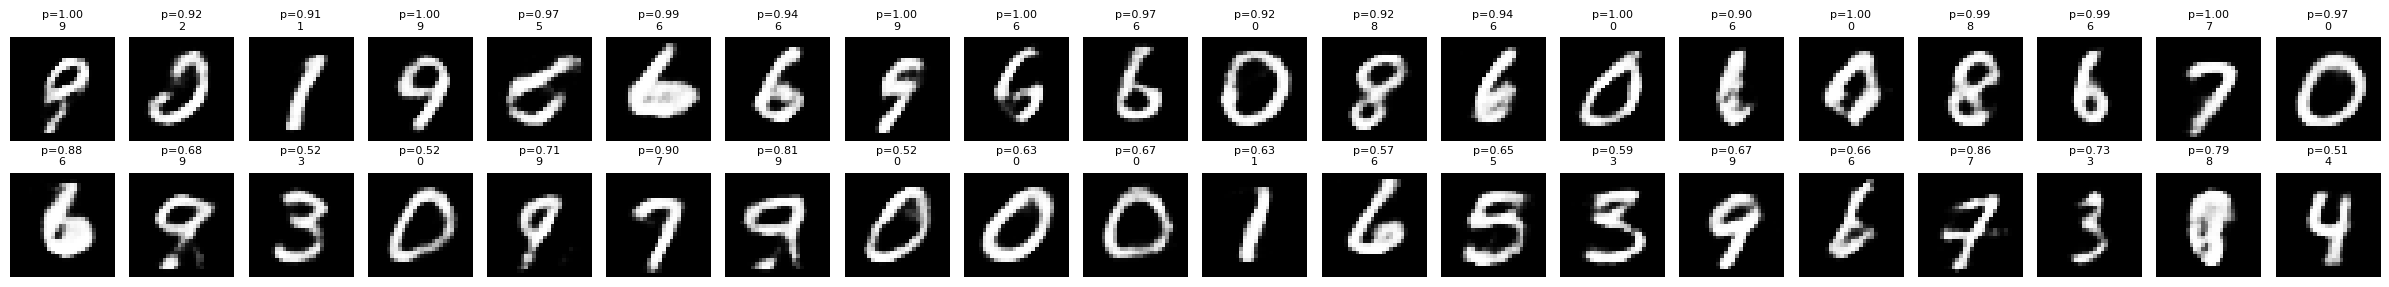

In [12]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# --- choose thresholds ---
t_high = 0.90
t_low  = 0.50

# --- masks ---
high_mask = probs >= t_high
mid_mask  = (probs >= t_low) & (probs < t_high)

high_idx = np.where(high_mask)[0]
mid_idx  = np.where(mid_mask)[0]

# --- pick random samples ---
n_show = 20  # how many to display per group
rng = np.random.default_rng(0)

sel_high = rng.choice(high_idx, size=min(n_show, len(high_idx)), replace=False)
sel_mid  = rng.choice(mid_idx,  size=min(n_show, len(mid_idx)),  replace=False)

# --- plot ---
fig, axes = plt.subplots(2, n_show, figsize=(n_show*1.2, 3))

for i, idx in enumerate(sel_high):
    img = synthetic_image[idx].squeeze().cpu().numpy()
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"p={probs[idx]:.2f}\n{synthetic_label[idx].item()}", fontsize=8)
    axes[0, i].axis("off")

for i, idx in enumerate(sel_mid):
    img = synthetic_image[idx].squeeze().cpu().numpy()
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title(f"p={probs[idx]:.2f}\n{synthetic_label[idx].item()}", fontsize=8)
    axes[1, i].axis("off")

axes[0,0].set_ylabel("High (p≥0.9)", fontsize=10)
axes[1,0].set_ylabel("Mid (0.5≤p<0.9)", fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# -*- coding: utf-8 -*-
"""
End-to-end CVAE pipeline that:
1) Trains on REAL MNIST (sample size is a parameter) -> saves model_00_real.pth
2) Iteratively refines K times WITHOUT saving any data:
   - Use current model to generate attempts
   - Filter on-the-fly with a discriminator (p > threshold)
   - Train the next CVAE ONLY on filtered stream
   - Save only model weights per round (no data saved)
"""

import os
import sys
import torch
import random
import numpy as np
from typing import Tuple, Optional
from torch.utils.data import IterableDataset, DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import torch.nn.functional as F

# Your local modules must be importable from ROOT
from cvae_model import CVAE, cvae_loss
from discriminator import Discriminator


# -----------------------------
# Helpers
# -----------------------------
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

def set_seed(seed=0):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

def safe_load(path: str, device: str):
    """Load state dict safely; silence FutureWarning when torch supports weights_only."""
    try:
        return torch.load(path, map_location=device, weights_only=True)  # torch >= 2.4
    except TypeError:
        return torch.load(path, map_location=device)


# -----------------------------
# REAL data training
# -----------------------------
def train_cvae_on_real(
    *,
    sample_size: int,
    latent_dim: int = 20,
    label_dim: int = 10,
    batch_size: int = 128,
    epochs: int = 200,
    lr: float = 1e-3,
    patience: int = 5,
    save_dir: str = "model_saved",
    save_name: str = "model_00_real.pth",
    device: Optional[str] = None,
    seed: int = 0,
) -> Tuple[torch.nn.Module, str]:
    """
    Train CVAE on real MNIST (first `sample_size` samples) and save weights.
    Only model weights are saved; no data saved anywhere.
    """
    set_seed(seed)
    ensure_dir(save_dir)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load MNIST train set
    transform = transforms.ToTensor()
    full_dataset = datasets.MNIST(root=os.path.join(ROOT, "data"), train=True, download=True, transform=transform)
    dataset = Subset(full_dataset, range(sample_size))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    # Init model/optimizer
    model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    save_path = os.path.join(save_dir, save_name)

    for ep in range(1, epochs + 1):
        torch.set_grad_enabled(True)
        model.train()
        total_loss = 0.0
        n_samples = 0

        for x, y in loader:
            # Flatten to [B, 784]; one-hot labels
            x = x.view(-1, 784).to(device)
            y = one_hot(y).to(device)

            opt.zero_grad()
            recon_x, mu, logvar = model(x, y)
            loss = cvae_loss(recon_x, x, mu, logvar)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader.dataset)
        print(f"[REAL] Epoch {ep}/{epochs} | Train Loss: {avg_loss:.6f}")

    torch.save(model.state_dict(), save_path)
    # Load best and return both model and path
    state = safe_load(save_path, device)
    model.load_state_dict(state)
    model.eval()
    print(f"[REAL] Saved model -> {save_path}")
    return model, save_path

def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels
import numpy as np
from sklearn.metrics import pairwise_distances
import torch, math
import torch.nn as nn
def get_embedder(discriminator: nn.Module) -> nn.Module:
    """
    Returns a module that outputs the penultimate 128-D embedding:
    Conv -> LeakyReLU -> Conv -> LeakyReLU -> Flatten -> Linear(64*7*7->128) -> LeakyReLU
    """
    layers = list(discriminator.net.children())[:-2]  # drop final Linear(128->1) and Sigmoid
    embedder = nn.Sequential(*layers)
    # share weights; keep device consistent
    embedder.to(next(discriminator.parameters()).device)
    embedder.eval()
    return embedder

def kcenter_greedy(emb, k, seed=0):
    M = emb.shape[0]
    if k <= 0: return np.empty(0, dtype=int)
    if M <= k: return np.arange(M, dtype=int)
    rng = np.random.default_rng(seed)
    centers = [int(rng.integers(M))]
    min_dist = pairwise_distances(emb[centers], emb).ravel()
    for _ in range(1, k):
        nxt = int(np.argmax(min_dist))
        centers.append(nxt)
        min_dist = np.minimum(min_dist, pairwise_distances(emb[[nxt]], emb).ravel())
    return np.array(centers, dtype=int)

def select_fixed_size_per_class_half_band(
    probs, labels_np, E_syn,
    top_pct=0.005,      
    next_pct=0.005,    
    keep_ratio=0.5,   
    num_classes=10,
    seed=0
):
   
    # to numpy
    if torch.is_tensor(probs): probs = probs.detach().cpu().numpy()
    probs = probs.reshape(-1)
    labels_np = np.asarray(labels_np).reshape(-1)
    E_syn = np.asarray(E_syn)

    all_high, all_div = [], []

    for c in range(num_classes):
        idx_c = np.where(labels_np == c)[0]
        Nc = len(idx_c)
        if Nc == 0:
            continue

        K_high = max(1, math.ceil(Nc * top_pct))
        K_band = max(0, min(Nc - K_high, math.ceil(Nc * next_pct)))  # 避免越界
        K_keep = max(0, min(K_band, int(round(K_band * keep_ratio)))) # 只保留 band 的一半

        order_c = idx_c[np.argsort(-probs[idx_c])]
        high_c  = order_c[:K_high]
        band_c  = order_c[K_high:K_high + K_band] 

        if K_keep > 0 and len(band_c) > 0:
            emb_div = E_syn[band_c]
            sel_local = kcenter_greedy(emb_div, k=min(K_keep, len(band_c)), seed=seed)
            div_c = band_c[sel_local]
        else:
            div_c = np.empty(0, dtype=int)

        all_high.append(high_c)
        all_div.append(div_c)

    high_idx = np.unique(np.concatenate(all_high)) if all_high else np.empty(0, dtype=int)
    div_idx  = np.unique(np.concatenate(all_div))  if all_div  else np.empty(0, dtype=int)
    final_idx = np.unique(np.concatenate([high_idx, div_idx]))
    return high_idx, div_idx, final_idx

def train_cvae_on_filtered_synthetic(
    data_model: torch.nn.Module,
    *,
    D: torch.nn.Module,
    filter_threshold: float=0.5,
    total_sample_size: int = 60000,
    latent_dim: int = 20,
    label_dim: int = 10,
    batch_size: int = 128,
    epochs: int = 200,
    lr: float = 1e-3,
    patience: int = 5,
    save_path: Optional[str] = None,
    device: Optional[str] = None,
) -> torch.nn.Module:
    """
    Train a CVAE using a streaming filtered dataset.
    Only model weights are saved. No data is written to disk.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
        model=data_model,
        total_samples=total_sample_size,
        latent_dim=latent_dim,
        num_classes=10,
        batch_size=10000,
        device=device
    )
    synthetic_loader = DataLoader(gen_imgs_before_filter, batch_size=512)

    all_probs = []

    with torch.no_grad():
        for batch in synthetic_loader:
            batch = batch.to(device)
            probs = D(batch)  # [batch_size, 1], already sigmoid activated
            all_probs.append(probs.cpu())

    all_probs = torch.cat(all_probs, dim=0)
    # Flatten probs to shape [N]
    probs = all_probs.squeeze(1)
    probs_list, emb_list = [], []
    N = gen_imgs_before_filter.shape[0]
    batch_size_scoring = 1024
    embedder = get_embedder(D).eval().to(device)
    D.eval()
    with torch.no_grad():
        for i in range(0, N, batch_size_scoring):
            xb = gen_imgs_before_filter[i:i+batch_size_scoring].to(device)
            pb = D(xb).squeeze(1).detach().cpu().numpy()       # D has Sigmoid -> probs
            hb = embedder(xb)                                   # (B,128)
            hb = F.normalize(hb, p=2, dim=1).cpu().numpy()      # L2 normalize for Euclidean
            probs_list.append(pb); emb_list.append(hb)
    probs = np.concatenate(probs_list, 0)                       # (N,)
    E_syn = np.concatenate(emb_list, 0)                         # (N,128)
    # Load images and labels
    images = gen_imgs_before_filter#data['images']      # [N, 1, 28, 28]
    labels = y_before_filter #data['labels']      # [N]
    
    labels_np = y_before_filter.detach().cpu().numpy() if torch.is_tensor(y_before_filter) else np.asarray(y_before_filter)

    _, _, mask = select_fixed_size_per_class_half_band(
        probs, labels_np, E_syn,
        top_pct=0.005,      
        next_pct=0.005,    
        keep_ratio=0.5,   
        num_classes=10,
        seed=0
    )

    # Apply mask
    filtered_images = images[mask]
    filtered_labels = labels[mask]

    print(f"Filtered {filtered_images.shape[0]} samples out of {images.shape[0]} total generated samples using threshold: highquality:{top_pct},next:")

    ######## filtered synthetic data training ########
    images = filtered_images  # shape: [N, 1, 28, 28]
    labels = filtered_labels  # shape: [N]

    # Preprocess: flatten images and convert labels to one-hot
    images = images.view(-1, 784)  # flatten to [N, 784]

    # Create dataset and dataloader
    dataset = TensorDataset(images, labels)
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize model
    model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if save_path is not None:
        ensure_dir(os.path.dirname(save_path))
    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x = x.view(-1, 784).to(device)
            y = one_hot(y).to(device)

            optimizer.zero_grad()
            recon_x, mu, logvar = model(x, y)
            loss = cvae_loss(recon_x, x, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch [{ep+1}/{epochs}], Train Loss: {avg_loss:.4f}")
        
   
    return model



In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Hyperparameters
latent_dim = 20
label_dim = 10
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/iter_models_only/model_00_real.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

/tmp/ipykernel_2344375/3164089365.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
/tmp/ipykernel_23443

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=3136, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Linear(in_features=128, out_features=1, bias=True)
    (8): Sigmoid()
  )
)

In [7]:
train_cvae_on_filtered_synthetic(model, D=D,epochs=1)

Filtered 450 samples out of 60000 total generated samples using threshold 0.5
Epoch [2/1], Train Loss: 517.6947


CVAE(
  (fc1): Linear(in_features=794, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=30, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)